## Libraries installation

In [ ]:
# !pip install catboost
# !pip install ipywidgets
# !pip install shap
# !pip install sklearn
# !jupyter nbextension enable --py widgetsnbextension

    ERROR: Command errored out with exit status 1:
     command: 'C:\Users\Nitish\anaconda3\python.exe' -c 'import io, os, sys, setuptools, tokenize; sys.argv[0] = '"'"'C:\\Users\\Nitish\\AppData\\Local\\Temp\\pip-install-476y9hfg\\sklearn_cad026cf445a49c9a728e9e448419d86\\setup.py'"'"'; __file__='"'"'C:\\Users\\Nitish\\AppData\\Local\\Temp\\pip-install-476y9hfg\\sklearn_cad026cf445a49c9a728e9e448419d86\\setup.py'"'"';f = getattr(tokenize, '"'"'open'"'"', open)(__file__) if os.path.exists(__file__) else io.StringIO('"'"'from setuptools import setup; setup()'"'"');code = f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' egg_info --egg-base 'C:\Users\Nitish\AppData\Local\Temp\pip-pip-egg-info-lzucbdlm'
         cwd: C:\Users\Nitish\AppData\Local\Temp\pip-install-476y9hfg\sklearn_cad026cf445a49c9a728e9e448419d86\
    Complete output (15 lines):
    The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
    rather than 'sklearn' f

    - if the 'sklearn' package is used by one of your dependencies,
      it would be great if you take some time to track which package uses
      'sklearn' instead of 'scikit-learn' and report it to their issue tracker
    - as a last resort, set the environment variable
      SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
    
    More information is available at
    https://github.com/scikit-learn/sklearn-pypi-package
    
    If the previous advice does not cover your use case, feel free to report it at
    https://github.com/scikit-learn/sklearn-pypi-package/issues/new
    ----------------------------------------
    ERROR: Command errored out with exit status 1:
     command: 'C:\Users\Nitish\anaconda3\python.exe' -c 'import io, os, sys, setuptools, tokenize; sys.argv[0] = '"'"'C:\\Users\\Nitish\\AppData\\Local\\Temp\\pip-install-476y9hfg\\sklearn_9b81c1855b5c4808a6d6caec30a8f94a\\setup.py'"'"'; __file__='"'"'C:\\Users\\Nitish\\AppData\\Local\\Temp\\pi

In [2]:
import os
import pandas as pd
import numpy as np

import catboost
print(catboost.__version__)

1.2.8


## Reading the data

In [3]:
df = pd.read_csv('https://gist.githubusercontent.com/meperezcuello/82a9f1c1c473d6585e750ad2e3c05a41/raw/d42d226d0dd64e7f5395a0eec1b9190a10edbc03/Medical_Cost.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Exploring the data

In [6]:
y = df['charges']
X = df.drop('charges', axis=1)

In [7]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


Categorical features declaration

In [8]:
cat_features = [1,3,4,5]
print(cat_features)

[1, 3, 4, 5]


# Training the first model

In [9]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(iterations=10)

model.fit(X, y, cat_features=cat_features, verbose=5)

Learning rate set to 0.5
0:	learn: 7787.0489866	total: 212ms	remaining: 1.91s
5:	learn: 4560.8501449	total: 546ms	remaining: 364ms
9:	learn: 4380.1688426	total: 879ms	remaining: 0us


In [10]:
model.predict(X)

array([19654.86890676,  4327.79540466,  6394.05757217, ...,
        3133.7350406 ,  2861.55162174, 34285.14154651], shape=(1338,))

# Working with dataset

There are several ways of passing dataset to training - using X,y (the initial matrix) or using Pool class.
Pool class is the class for storing the dataset. In the next few blocks we'll explore the ways to create a Pool object.

You can use Pool class if the dataset has more than just X and y (for example, it has sample weights or groups) or if the dataset is large and it takes long time to read it into python.

In [11]:
from catboost import Pool
pool = Pool(data=X, label=y, cat_features=cat_features)

## Split your data into train and validation

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features
)

validation_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features
)

## Selecting the objective function

In [13]:
model = CatBoostRegressor(
    iterations=5,
    learning_rate=0.1,
    loss_function='RMSE'
)
model.fit(train_pool, eval_set=validation_pool, verbose=False)

print('Model is fitted: {}'.format(model.is_fitted()))
print('Model params:\n{}'.format(model.get_params()))

Model is fitted: True
Model params:
{'iterations': 5, 'learning_rate': 0.1, 'loss_function': 'RMSE'}


## Stdout of the training

In [14]:
model = CatBoostRegressor(
    iterations=15,
    verbose=5,
)
model.fit(train_pool, eval_set=validation_pool);

Learning rate set to 0.5
0:	learn: 7608.2906506	test: 7667.5765651	best: 7667.5765651 (0)	total: 37.1ms	remaining: 520ms
5:	learn: 4604.5635186	test: 4106.7789446	best: 4106.7789446 (5)	total: 466ms	remaining: 699ms
10:	learn: 4429.2010329	test: 4065.7452484	best: 4039.2627286 (8)	total: 865ms	remaining: 314ms
14:	learn: 4259.1387065	test: 4064.9212176	best: 4039.2627286 (8)	total: 1.22s	remaining: 0us

bestTest = 4039.262729
bestIteration = 8

Shrink model to first 9 iterations.


## Metrics calculation and graph plotting

In [15]:
model = CatBoostRegressor(
    iterations=50,
    learning_rate=0.5,
    loss_function='RMSE'
)

model.fit(
    train_pool,
    eval_set=validation_pool,
    verbose=False,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

## Model comparison

In [16]:
model1 = CatBoostRegressor(
    learning_rate=0.7,
    iterations=100,
    train_dir='salman'
)

model2 = CatBoostRegressor(
    learning_rate=0.01,
    iterations=100,
    train_dir='shahrukh'
)

model1.fit(train_pool, eval_set=validation_pool, verbose=20)
model2.fit(train_pool, eval_set=validation_pool, verbose=20)

0:	learn: 6225.1861330	test: 6028.1142804	best: 6028.1142804 (0)	total: 47.4ms	remaining: 4.69s
20:	learn: 4064.4776624	test: 4230.9297514	best: 4166.3947766 (10)	total: 1.89s	remaining: 7.13s
40:	learn: 3595.5874566	test: 4293.5019510	best: 4166.3947766 (10)	total: 3.9s	remaining: 5.61s
60:	learn: 3118.0919822	test: 4405.3245592	best: 4166.3947766 (10)	total: 5.91s	remaining: 3.78s
80:	learn: 2816.0249682	test: 4386.6941790	best: 4166.3947766 (10)	total: 7.79s	remaining: 1.83s
99:	learn: 2551.5441301	test: 4438.5918733	best: 4166.3947766 (10)	total: 9.54s	remaining: 0us

bestTest = 4166.394777
bestIteration = 10

Shrink model to first 11 iterations.
0:	learn: 11879.7932856	test: 12514.7821306	best: 12514.7821306 (0)	total: 42.6ms	remaining: 4.22s
20:	learn: 10298.1582508	test: 10760.1524741	best: 10760.1524741 (20)	total: 1.68s	remaining: 6.3s
40:	learn: 9025.1625771	test: 9336.0675800	best: 9336.0675800 (40)	total: 3.64s	remaining: 5.24s
60:	learn: 8017.1219457	test: 8188.6932839	bes

In [17]:
from catboost import MetricVisualizer
MetricVisualizer(['salman', 'shahrukh']).start()

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

## Best iteration

In [18]:
model = CatBoostRegressor(
    iterations=100,
    use_best_model=True
)

model.fit(
    train_pool,
    eval_set=validation_pool,
    verbose=False,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [19]:
print('Tree count: ' + str(model.tree_count_))

Tree count: 36


## Cross-validation

In [20]:
from catboost import cv

params = {
    'loss_function': 'RMSE',
    'iterations': 80,
    # 'custom_loss': 'MAE',
    'learning_rate': 0.5,
}

cv_data = cv(
    params = params,
    pool = train_pool,
    fold_count=5,
    shuffle=True,
    plot=True,
    stratified=False
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
0:	learn: 11020.4170379	test: 10229.5747867	best: 10229.5747867 (0)	total: 51.9ms	remaining: 4.1s
1:	learn: 7564.1037916	test: 7145.8261298	best: 7145.8261298 (1)	total: 142ms	remaining: 5.52s
2:	learn: 5706.4232752	test: 5673.1239325	best: 5673.1239325 (2)	total: 200ms	remaining: 5.14s
3:	learn: 4959.6268650	test: 5203.0959648	best: 5203.0959648 (3)	total: 243ms	remaining: 4.62s
4:	learn: 4702.2309638	test: 5082.9447107	best: 5082.9447107 (4)	total: 298ms	remaining: 4.47s
5:	learn: 4593.7638406	test: 5015.0822851	best: 5015.0822851 (5)	total: 387ms	remaining: 4.78s
6:	learn: 4503.3455425	test: 5012.9967244	best: 5012.9967244 (6)	total: 446ms	remaining: 4.65s
7:	learn: 4426.9323711	test: 4996.7833473	best: 4996.7833473 (7)	total: 532ms	remaining: 4.79s
8:	learn: 4273.4163679	test: 5002.4063084	best: 4996.7833473 (7)	total: 645ms	remaining: 5.08s
9:	learn: 4212.7765043	test: 5005.3501485	best: 4996.7833473 (7)	total: 745ms	remaining: 5.21s
10:	learn: 4201.4802978	

5:	learn: 4649.4133555	test: 4673.8593232	best: 4673.8593232 (5)	total: 247ms	remaining: 3.04s
6:	learn: 4521.9702175	test: 4643.9968449	best: 4643.9968449 (6)	total: 389ms	remaining: 4.06s
7:	learn: 4466.0659478	test: 4619.3017739	best: 4619.3017739 (7)	total: 481ms	remaining: 4.33s
8:	learn: 4452.8115017	test: 4616.4582962	best: 4616.4582962 (8)	total: 508ms	remaining: 4s
9:	learn: 4423.0457974	test: 4619.0858737	best: 4616.4582962 (8)	total: 547ms	remaining: 3.83s
10:	learn: 4365.0165665	test: 4640.8775786	best: 4616.4582962 (8)	total: 585ms	remaining: 3.67s
11:	learn: 4311.2295692	test: 4627.1983901	best: 4616.4582962 (8)	total: 627ms	remaining: 3.55s
12:	learn: 4297.0272838	test: 4628.2718548	best: 4616.4582962 (8)	total: 665ms	remaining: 3.43s
13:	learn: 4286.3299905	test: 4636.3559770	best: 4616.4582962 (8)	total: 690ms	remaining: 3.25s
14:	learn: 4266.9240108	test: 4638.4767318	best: 4616.4582962 (8)	total: 732ms	remaining: 3.17s
15:	learn: 4210.0247394	test: 4587.9789712	best:

12:	learn: 4365.8213368	test: 4947.4064804	best: 4941.9638476 (11)	total: 477ms	remaining: 2.46s
13:	learn: 4297.6904399	test: 4953.2387554	best: 4941.9638476 (11)	total: 511ms	remaining: 2.41s
14:	learn: 4264.0176652	test: 4942.2558073	best: 4941.9638476 (11)	total: 551ms	remaining: 2.39s
15:	learn: 4263.9760530	test: 4942.2795766	best: 4941.9638476 (11)	total: 569ms	remaining: 2.28s
16:	learn: 4194.4583216	test: 4956.2103957	best: 4941.9638476 (11)	total: 604ms	remaining: 2.24s
17:	learn: 4177.2163130	test: 4972.3182198	best: 4941.9638476 (11)	total: 649ms	remaining: 2.23s
18:	learn: 4135.7086403	test: 4995.3827497	best: 4941.9638476 (11)	total: 696ms	remaining: 2.23s
19:	learn: 4090.7255815	test: 4978.6508306	best: 4941.9638476 (11)	total: 736ms	remaining: 2.21s
20:	learn: 4067.6335594	test: 4993.0940566	best: 4941.9638476 (11)	total: 778ms	remaining: 2.19s
21:	learn: 4039.5147590	test: 4988.5760714	best: 4941.9638476 (11)	total: 820ms	remaining: 2.16s
22:	learn: 3993.0884856	test: 

18:	learn: 4240.1736439	test: 4254.2847898	best: 4212.4394042 (14)	total: 797ms	remaining: 2.56s
19:	learn: 4226.6773532	test: 4261.1777266	best: 4212.4394042 (14)	total: 842ms	remaining: 2.52s
20:	learn: 4170.5889901	test: 4292.3632193	best: 4212.4394042 (14)	total: 876ms	remaining: 2.46s
21:	learn: 4143.6752107	test: 4310.7636998	best: 4212.4394042 (14)	total: 920ms	remaining: 2.43s
22:	learn: 4120.9147475	test: 4310.3943203	best: 4212.4394042 (14)	total: 959ms	remaining: 2.38s
23:	learn: 4114.2749839	test: 4306.1255011	best: 4212.4394042 (14)	total: 1.02s	remaining: 2.38s
24:	learn: 4070.4173959	test: 4328.6430549	best: 4212.4394042 (14)	total: 1.06s	remaining: 2.33s
25:	learn: 4048.1380189	test: 4335.0471061	best: 4212.4394042 (14)	total: 1.1s	remaining: 2.29s
26:	learn: 4039.0828386	test: 4343.9869147	best: 4212.4394042 (14)	total: 1.15s	remaining: 2.25s
27:	learn: 4025.3041191	test: 4345.3912476	best: 4212.4394042 (14)	total: 1.2s	remaining: 2.24s
28:	learn: 4017.0783250	test: 43

25:	learn: 3806.8308577	test: 5131.7108955	best: 4979.0830369 (11)	total: 1.45s	remaining: 3.01s
26:	learn: 3770.6279696	test: 5120.3827160	best: 4979.0830369 (11)	total: 1.5s	remaining: 2.94s
27:	learn: 3750.1894745	test: 5123.8406426	best: 4979.0830369 (11)	total: 1.54s	remaining: 2.87s
28:	learn: 3719.9160534	test: 5157.7968127	best: 4979.0830369 (11)	total: 1.6s	remaining: 2.81s
29:	learn: 3695.1091993	test: 5169.8158279	best: 4979.0830369 (11)	total: 1.66s	remaining: 2.76s
30:	learn: 3653.4168627	test: 5196.6305152	best: 4979.0830369 (11)	total: 1.72s	remaining: 2.71s
31:	learn: 3603.9417253	test: 5222.2646403	best: 4979.0830369 (11)	total: 1.77s	remaining: 2.66s
32:	learn: 3589.9610309	test: 5239.5938820	best: 4979.0830369 (11)	total: 1.82s	remaining: 2.6s
33:	learn: 3577.4373637	test: 5241.5013788	best: 4979.0830369 (11)	total: 1.87s	remaining: 2.53s
34:	learn: 3568.4317043	test: 5241.7972321	best: 4979.0830369 (11)	total: 1.92s	remaining: 2.47s
35:	learn: 3562.2101193	test: 523

In [21]:
cv_data

,iterations,test-RMSE-mean,test-RMSE-std,train-RMSE-mean,train-RMSE-std
0,0,10910.552582,1079.964769,10858.930456,177.928727
1,1,7688.131595,759.830751,7532.286916,103.499961
2,2,5878.931108,475.681733,5702.507158,79.949880
3,3,5197.244618,331.709921,5009.393445,76.115483
4,4,4949.841276,291.660952,4760.460059,72.409281
...,...,...,...,...,...
75,75,5053.360113,403.637921,2913.615877,114.332149
76,76,5053.810285,400.191665,2894.848321,114.439372
77,77,5049.573600,404.112575,2878.155614,108.647442
78,78,5054.757932,409.054392,2864.293536,117.425037


In [22]:
best_value = np.min(cv_data['test-RMSE-mean'])
best_iter = np.argmin(cv_data['test-RMSE-mean'])

print('Best validation RMSE score: {:.4f}±{:.4f} on iteration {}'.format(
    best_value,
    cv_data['test-RMSE-mean'][best_iter],
    best_iter)
)

Best validation RMSE score: 4760.4100±4760.4100 on iteration 16


## Hyperparameter Tuning

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "learning_rate": [0.001, 0.01, 0.5],
}

clf = CatBoostRegressor(
    iterations=20,
    cat_features=cat_features,
    verbose=20
)
grid_search = GridSearchCV(clf, param_grid=param_grid, cv=3)
results = grid_search.fit(X_train, y_train)
results.best_estimator_.get_params()

0:	learn: 12101.1885964	total: 55.5ms	remaining: 1.05s
19:	learn: 11945.5933585	total: 1.57s	remaining: 0us
0:	learn: 11968.0006121	total: 71.2ms	remaining: 1.35s
19:	learn: 11808.9334478	total: 1.49s	remaining: 0us
0:	learn: 11816.0675780	total: 61.5ms	remaining: 1.17s
19:	learn: 11653.8141827	total: 1.57s	remaining: 0us
0:	learn: 12021.0930219	total: 45.5ms	remaining: 864ms
19:	learn: 10563.0000735	total: 1.63s	remaining: 0us
0:	learn: 11893.2730390	total: 73.6ms	remaining: 1.4s
19:	learn: 10441.0750438	total: 1.55s	remaining: 0us
0:	learn: 11738.7280820	total: 73.7ms	remaining: 1.4s
19:	learn: 10253.6015209	total: 1.58s	remaining: 0us
0:	learn: 7978.5386760	total: 46.5ms	remaining: 883ms
19:	learn: 4298.3894185	total: 1.72s	remaining: 0us
0:	learn: 8058.9321400	total: 69.4ms	remaining: 1.32s
19:	learn: 4061.8040490	total: 1.95s	remaining: 0us
0:	learn: 7780.7621946	total: 155ms	remaining: 2.95s
19:	learn: 3880.3716319	total: 2.42s	remaining: 0us
0:	learn: 7608.2906506	total: 64.5ms	

{'iterations': 20,
 'loss_function': 'RMSE',
 'verbose': 20,
 'cat_features': [1, 3, 4, 5],
 'learning_rate': 0.5}

## Overfitting Detector

In [24]:
model_with_early_stop = CatBoostRegressor(
    iterations=200,
    learning_rate=0.5,
    early_stopping_rounds=20
)

model_with_early_stop.fit(
    train_pool,
    eval_set=validation_pool,
    verbose=False,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [25]:
print(model_with_early_stop.tree_count_)

19


### Overfitting Detector with eval metric

In [26]:
# it's not tracking the r2 score, just shows the value of r2 score when the training got stopped

model_with_early_stop = CatBoostRegressor(
    eval_metric='R2',
    iterations=200,
    learning_rate=0.2,
    early_stopping_rounds=20
)
model_with_early_stop.fit(
    train_pool,
    eval_set=validation_pool,
    verbose=False,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [27]:
print(model_with_early_stop.tree_count_)

76


## Model predictions

In [28]:
model = CatBoostRegressor(iterations=200, learning_rate=0.03)
model.fit(train_pool, verbose=50)

0:	learn: 11698.0681489	total: 79.3ms	remaining: 15.8s
50:	learn: 5562.4329865	total: 4.27s	remaining: 12.5s
100:	learn: 4610.5616517	total: 8.73s	remaining: 8.56s
150:	learn: 4404.2985249	total: 13.3s	remaining: 4.31s
199:	learn: 4289.2492600	total: 18s	remaining: 0us


In [29]:
print(model.predict(X_test))

[13010.33565912 10392.71373727 44809.15103974 13783.61839406
 11203.52985749  4841.91062809  3567.67299567 13640.89543817
  8272.20274849  7064.37999133  6564.62595016 12266.91951971
  9273.62415808  4943.04035862 20081.02357121 12271.37863145
 13525.11900548  6165.75793885  7628.97484448 32181.14535273
 24398.94944378 13973.14208301 11997.59862092 25269.25362529
  3600.32254066  7218.75154912  4389.37025771  8444.36936883
  4558.51510575 10231.83507136  8555.26029751 46289.30238111
 13706.8965822  11992.98656571 17723.60094225  4774.02771564
 10078.30252908 38838.58629654 40256.85224088  3593.86536569
  5485.63669194  4087.64952817 22110.94581569 46091.57207277
 36934.22900537  6134.40984172 12282.77077304  7804.06696728
  5646.60122523 12678.07486878  4509.23234554  5642.2015661
 25015.87923275 45124.90141922 12209.24625707  4955.94678159
  3882.54099003 11203.30002088  8629.96132859 15036.48185943
  3129.55269257 43372.95110072 15973.01704087 11950.02588415
 12440.72719785 12923.899

In [30]:
predictions = []
for prediction in model.staged_predict(ntree_end=5, data=X_test):
    predictions.append(prediction)


In [31]:
predictions

[array([13225.53093061, 13147.27384668, 13963.30183006, 13225.53093061,
        13201.18164062, 12972.07227189, 12972.07227189, 13113.01579599,
        12983.13870651, 12983.13870651, 12972.07227189, 13147.27384668,
        12983.13870651, 12972.07227189, 13378.65763743, 13147.27384668,
        13207.20800089, 12983.13870651, 12972.07227189, 13922.7581837 ,
        13463.76052899, 13225.53093061, 13225.53093061, 13463.76052899,
        12983.13870651, 12983.13870651, 12972.17558148, 12983.13870651,
        12972.07227189, 13113.01579599, 12972.07227189, 14083.47582012,
        13225.53093061, 13225.53093061, 13378.65763743, 12972.07227189,
        13113.01579599, 13922.7581837 , 13922.7581837 , 12983.13870651,
        12972.07227189, 12972.07227189, 13378.65763743, 14083.47582012,
        13922.7581837 , 12983.13870651, 13147.27384668, 12972.07227189,
        12972.07227189, 13207.20800089, 12983.13870651, 12972.07227189,
        13463.76052899, 13963.30183006, 13225.53093061, 12983.13

## Metric evaluation on a new dataset

In [32]:
metrics = model.eval_metrics(
    data=validation_pool,
    metrics=['R2'],
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [33]:
print('R2 score:\n{}'.format(np.array(metrics['R2'])))

R2 score:
[0.0476055  0.09419045 0.13704105 0.17107418 0.20627582 0.233224
 0.26805049 0.29887582 0.32762497 0.35691078 0.38184743 0.40846397
 0.42678117 0.45101735 0.470458   0.48810145 0.50700867 0.5247933
 0.54455093 0.56189701 0.57897667 0.59015672 0.60657234 0.62153603
 0.63517158 0.64923001 0.66258151 0.67504709 0.68702123 0.69824218
 0.70507549 0.7139939  0.72414011 0.73264667 0.74030284 0.74863311
 0.75491661 0.76139972 0.76834235 0.77522373 0.78041802 0.78591667
 0.79164642 0.79729469 0.80240781 0.80705852 0.81100184 0.81559341
 0.81963746 0.82371742 0.82593967 0.82927444 0.83291623 0.83641682
 0.83927108 0.84235281 0.84496723 0.84755655 0.85033869 0.8527761
 0.85445654 0.85634335 0.858658   0.86058071 0.86239015 0.86380236
 0.86473702 0.86619038 0.86756072 0.86905834 0.87093029 0.87247498
 0.87353561 0.87497055 0.87617089 0.87741797 0.87866891 0.87984704
 0.88071964 0.88177728 0.88288225 0.88367337 0.88433998 0.88499502
 0.88585792 0.8865104  0.88707518 0.88775974 0.88804194 

## Feature importances

### Prediction values change

Default feature importances for binary classification is PredictionValueChange - how much on average does the model change when the feature value changes.
These feature importances are non negative.
They are normalized and sum to 1, so you can look on these values like percentage of importance.

In [34]:
np.array(model.get_feature_importance(prettified=True))

array([['smoker', 76.31805508436925],
       ['bmi', 12.693505668368188],
       ['age', 8.603279276464882],
       ['children', 1.363812132906847],
       ['region', 0.8408094101656046],
       ['sex', 0.1805384277252453]], dtype=object)

<Axes: title={'center': 'Feature Importance'}>

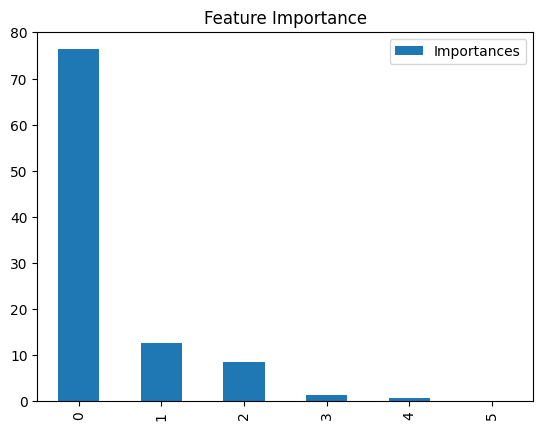

In [35]:
# Plot feature importances
model.get_feature_importance(prettified=True).plot(kind='bar', title='Feature Importance')

### Loss function change

The non default feature importance approximates how much the optimized loss function will change if the value of the feature changes.
This importances might be negative if the feature has bad influence on the loss function.
The importances are not normalized, the absolute value of the importance has the same scale as the optimized loss value.
To calculate this importance value you need to pass train_pool as an argument.

In [36]:
np.array(model.get_feature_importance(
    train_pool,
    type='LossFunctionChange',
    prettified=True
))

array([['smoker', 6262.829741268003],
       ['age', 1292.5628566317873],
       ['bmi', 959.5073119629296],
       ['children', 87.2395469076614],
       ['region', 22.088282256054754],
       ['sex', 5.413669543065225]], dtype=object)

In [37]:
# Compute the interaction strengths
interaction_strengths = model.get_feature_importance(
    train_pool,
    type='Interaction',
)

interaction_strengths

array([[0.        , 3.        , 8.89546955],
       [0.        , 5.        , 8.353932  ],
       [2.        , 5.        , 8.07461239],
       [0.        , 2.        , 7.67368015],
       [2.        , 3.        , 6.82609129],
       [3.        , 5.        , 6.73720189]])

### Shap values

In [38]:
print(model.predict([X.iloc[1,:]]))
print(model.predict([X.iloc[91,:]]))

[4599.29080154]
[12762.9175922]


In [39]:
shap_values = model.get_feature_importance(
    validation_pool,
    'ShapValues'
)
expected_value = shap_values[0,-1]
shap_values = shap_values[:,:-1]
print(shap_values.shape)

(268, 6)


In [40]:
proba = model.predict([X.iloc[1,:]])[0]
raw = model.predict([X.iloc[1,:]], prediction_type='RawFormulaVal')[0]
print('Probabilities', proba)
print('Raw formula value %.4f' % raw)

Probabilities 4599.290801539781
Raw formula value 4599.2908


In [41]:
import shap

shap.initjs()
shap.force_plot(expected_value, shap_values[1,:], X_test.iloc[1,:])

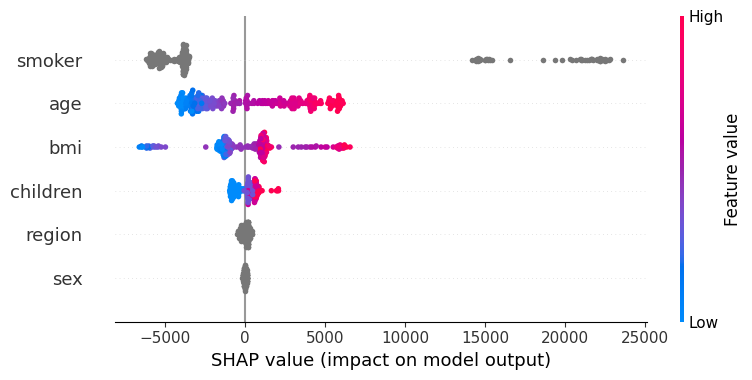

In [42]:
shap.summary_plot(shap_values, X_test)

## Snapshotting

The snapshotting feature in CatBoost is a very useful functionality that allows the training process to be paused and later resumed from the same point. This is particularly beneficial when training large models on extensive datasets, or in environments where long-running processes are subject to interruptions.

In [43]:
model = CatBoostRegressor(
    iterations=1000,
    save_snapshot=True,
    snapshot_file='snapshot.bkp',
    snapshot_interval=1
)

model.fit(train_pool, eval_set=validation_pool, verbose=10)

Learning rate set to 0.051465
0:	learn: 11501.8567610	test: 12090.6116683	best: 12090.6116683 (0)	total: 113ms	remaining: 1m 53s
10:	learn: 8242.8820804	test: 8446.3282841	best: 8446.3282841 (10)	total: 875ms	remaining: 1m 18s
20:	learn: 6404.7781888	test: 6301.8319053	best: 6301.8319053 (20)	total: 1.73s	remaining: 1m 20s
30:	learn: 5467.7380728	test: 5181.8433043	best: 5181.8433043 (30)	total: 2.51s	remaining: 1m 18s
40:	learn: 4963.2455390	test: 4557.7123958	best: 4557.7123958 (40)	total: 3.37s	remaining: 1m 18s
50:	learn: 4710.8292066	test: 4262.4952635	best: 4262.4952635 (50)	total: 4.21s	remaining: 1m 18s
60:	learn: 4565.4865532	test: 4115.8371195	best: 4115.8371195 (60)	total: 5.06s	remaining: 1m 17s
70:	learn: 4490.4849121	test: 4060.7405790	best: 4060.7405790 (70)	total: 5.79s	remaining: 1m 15s
80:	learn: 4419.4072897	test: 4015.2193505	best: 4015.2193505 (80)	total: 6.63s	remaining: 1m 15s
90:	learn: 4379.5174838	test: 3995.4873847	best: 3995.4873847 (90)	total: 7.47s	remaini

## Saving the model

In [44]:
model = CatBoostRegressor(iterations=10)
model.fit(train_pool, eval_set=validation_pool, verbose=False)
model.save_model('catboost_model.bin')
model.save_model('catboost_model.json', format='json')

In [45]:
model.load_model('catboost_model.bin')
print(model.get_params())
print(model.learning_rate_)

{'loss_function': 'RMSE', 'iterations': 10, 'verbose': 0}
0.5


## Training on GPU

In [ ]:
%%time
from catboost import CatBoostRegressor


model = CatBoostRegressor(iterations=1000,
                           task_type="GPU",
                           devices='0')
model.fit(X_train,
          y_train,
          cat_features=cat_features,
          verbose=False)



## Missing values

In [ ]:
from catboost import CatBoostClassifier, Pool
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create a simple dataset with missing values
data = {
    'Age': [25, np.nan, 35, 45, np.nan],  # Missing values in the 'Age' feature
    'Salary': [50000, 60000, np.nan, 70000, 80000],  # Missing values in the 'Salary' feature
    'Target': [1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

df

,Age,Salary,Target
0,25.0,50000.0,1
1,NaN,60000.0,0
2,35.0,NaN,1
3,45.0,70000.0,0
4,NaN,80000.0,1


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Target', axis=1),
    df['Target'],
    test_size=0.2,
    random_state=42
)

# Initialize a CatBoost classifier
model = CatBoostClassifier(
    iterations=10,
    learning_rate=0.5,
    depth=2,
    verbose=False
)

# Train the model directly on data with missing values
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)
print("Predictions:", predictions)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)



Predictions: [1]
Accuracy: 0.0
